In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('notable_ai_models.csv')
df['Year'] = pd.to_datetime(df['Publication date'], errors='coerce').dt.year
df = df[(df['Year'] >= 1950) & (df['Year'] <= 2025)].copy() 

def map_affiliation(raw):
    if pd.isna(raw):
        return 'Other'
    tags = set(t.strip() for t in raw.split(','))
    if tags == {'Industry'}:
        return 'Industry'
    if tags == {'Academia'}:
        return 'Academia'
    if tags == {'Industry', 'Academia'}:
        return 'Academia and industry collaboration'
    return 'Other'

df['Affiliation'] = df['Organization categorization'].apply(map_affiliation) #affiliation mapping

# Choosing which domains get their own panel
 
check how often each domain tag actually appears before deciding which ones to keep.

In [2]:
raw_tags = df['Domain'].apply(lambda raw: ['Untagged'] if pd.isna(raw) else [t.strip() for t in raw.split(',')]) #create a list of tags for each row
tag_counts = raw_tags.explode().value_counts() #count the frequency of each tag
print(tag_counts)

top5_by_frequency = tag_counts.head(5).index.tolist() #top 5 domains
print('Top 5 by raw frequency:', top5_by_frequency)

Domain
Language             497
Vision               334
Multimodal           105
Image generation      56
Speech                55
Games                 51
Biology               48
Video                 46
Robotics              28
Audio                 22
Mathematics           17
Other                 17
Recommendation        15
3D modeling            9
Medicine               8
Earth science          7
Search                 3
Untagged               3
Materials science      2
Driving                1
Name: count, dtype: int64
Top 5 by raw frequency: ['Language', 'Vision', 'Multimodal', 'Image generation', 'Speech']


# Finalising the panel list

Top 5 by frequency and Biology, kept for the reversal it shows. Everything else folds into one Other domains panel. 7 panels total.

In [3]:
TOP_DOMAINS = ['Language', 'Vision', 'Multimodal', 'Image generation', 'Speech', 'Biology']

def bucket_domains(raw): #put the domains into the top 5 and "Other domains"
    if pd.isna(raw):
        return ['Other domains']
    tags = [t.strip() for t in raw.split(',')] 
    return sorted(set(t if t in TOP_DOMAINS else 'Other domains' for t in tags))

df['DomainBucket'] = df['Domain'].apply(bucket_domains) 
exploded = df.explode('DomainBucket').reset_index(drop=True) #one row per tagged domain

agg = (exploded.groupby(['DomainBucket', 'Year', 'Affiliation'])
       .size().reset_index(name='Count')) #aggregate counts of each domain per year and affiliation

panel_order = TOP_DOMAINS + ['Other domains'] #domains first and aggregate panel last
totals = exploded['DomainBucket'].value_counts().to_dict()

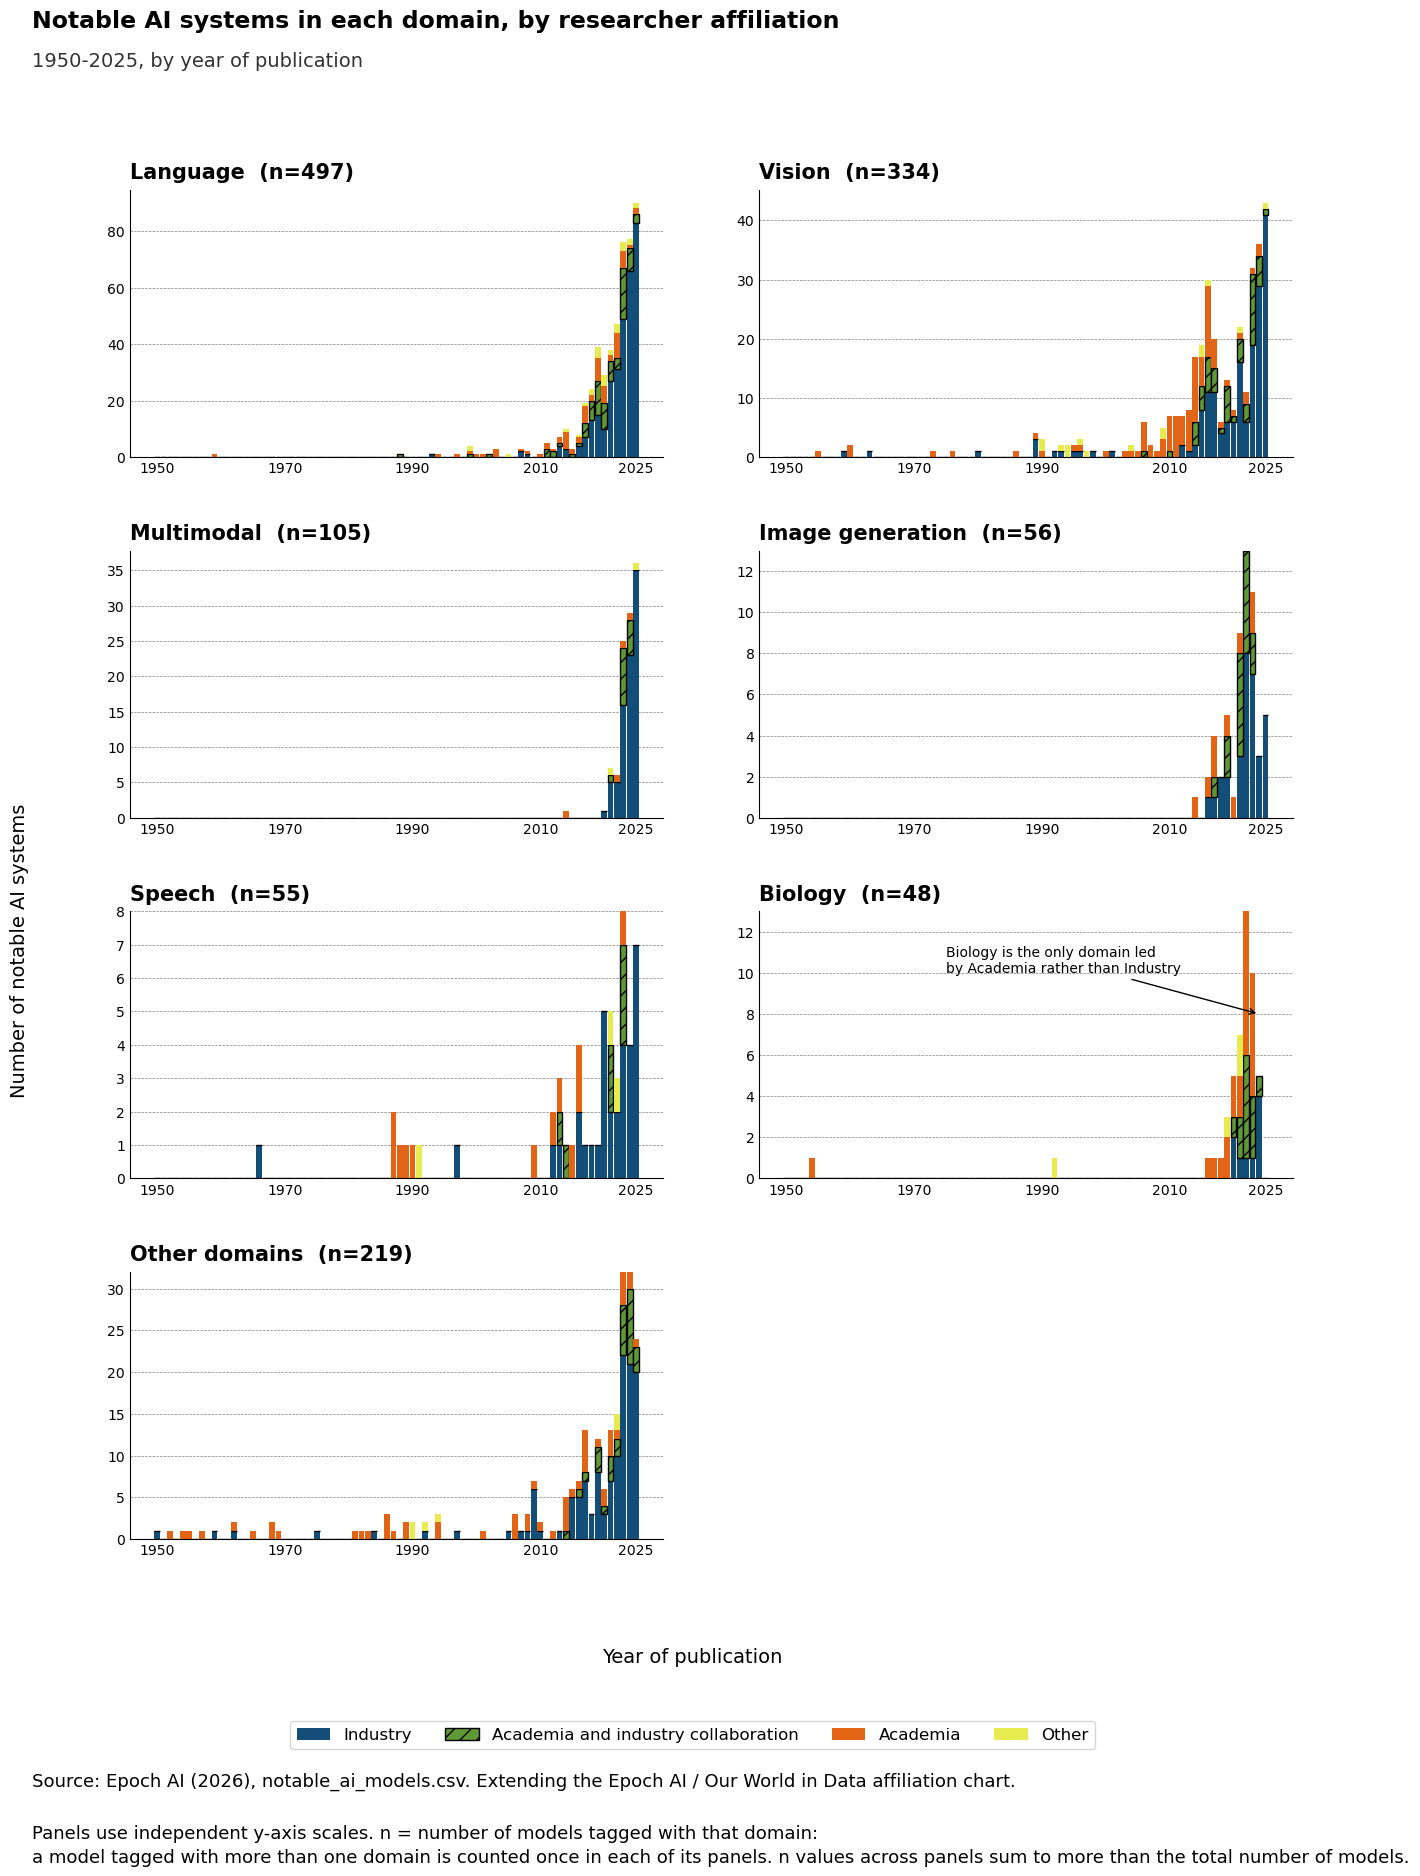

In [8]:
categories = ['Industry', 'Academia and industry collaboration', 'Academia', 'Other']
years = range(1950, 2026)

color_map = {
    'Industry': '#124E78',
    'Academia and industry collaboration': '#609836', 
    'Academia': '#E36414',
    'Other': '#E8EB4E'
}

hatch_map = {
    'Industry': '',
    'Academia and industry collaboration': '//',
    'Academia': '',
    'Other': ''
}

fig, axes = plt.subplots(4, 2, figsize=(15, 19), sharex=True)
axes = axes.flatten()
fig.delaxes(axes[7]) #7 domains

for i, domain in enumerate(panel_order): #creates the small multiples for each domain
    ax = axes[i]
    sub = agg[agg['DomainBucket'] == domain] #aggregate data for the current domain
    pivot = (sub.pivot(index='Year', columns='Affiliation', values='Count')
             .reindex(index=years, columns=categories).fillna(0)) #pivot to have years as index and affiliations as columns

    bottom = pd.Series(0, index=pivot.index, dtype=float) #bottom for stacked bar chart
    for category in categories: #categories of affiliation
        bars = ax.bar(pivot.index, pivot[category], bottom=bottom, width=0.9,
                       label=category, color=color_map[category], hatch=hatch_map[category])
        if hatch_map[category]:
            for b in bars:
                b.set_edgecolor('black') #hatch pattern edge color
        bottom += pivot[category]

    ax.set_title(f"{domain}  (n={totals[domain]})", loc='left', fontsize=15, fontweight='bold', pad=8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='gray', linestyle='dashed', linewidth=0.5)
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis='both', length=0, labelsize=10)
    ax.set_xticks([1950, 1970, 1990, 2010, 2025])
    ax.tick_params(axis='x', labelbottom=True)

    bio_ax = axes[panel_order.index('Biology')] #biology panel for annotation
bio_ax.annotate(
    "Biology is the only domain led\nby Academia rather than Industry",
    xy=(2024, 8), xytext=(1975, 10),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
) #annotation 

fig.suptitle('Notable AI systems in each domain, by researcher affiliation',
             fontsize=17, fontweight='bold', x=0.06, y=0.995, ha='left')
fig.text(0.06, 0.965, '1950-2025, by year of publication', fontsize=14, color='#333333')
fig.supylabel('Number of notable AI systems', fontsize=14, x=0.045)
fig.text(0.5, 0.125, 'Year of publication', ha='center', fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()
order = [labels.index(c) for c in categories]
fig.legend([handles[o] for o in order], [labels[o] for o in order],
           loc='lower center', bbox_to_anchor=(0.5, 0.075), ncol=4, frameon=True, fontsize=12)

fig.text(
    0.06, 0.020,
    "Panels use independent y-axis scales. n = number of models tagged with that domain:\n"
    "a model tagged with more than one domain is counted once in each of its panels. "
    "n values across panels sum to more than the total number of models.",
    fontsize=13, color="#000000",
    linespacing=1.4
)

fig.text(
    0.06, 0.060,
    "Source: Epoch AI (2026), notable_ai_models.csv. Extending the Epoch AI / Our World in Data affiliation chart.",
    fontsize=13, color="#010101"
)

fig.subplots_adjust(top=0.90, bottom=0.19, hspace=0.35, wspace=0.18)
plt.savefig('module7_domain_affiliation_smallmultiples.png', dpi=200, facecolor='white', bbox_inches='tight')
plt.show()